In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data =pd.read_csv("SmartCardInfo.csv")

In [5]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

DATA PREPROCESSING

Handle Missing Value

In [5]:
data["Income"] =data["Income"].fillna(data["Income"].median())

Feature Enginnering

In [7]:
# delete some feature and add sum feature
# we create  new age colomn age effect more in e commerce web
# ml model donot understand the date value we change into pandas datetime
data["Age"] =2026-data["Year_Birth"]

In [8]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [8]:
#cutomer joining date
data["Dt_Customer"] =pd.to_datetime(data["Dt_Customer"],dayfirst =True)
# daytime first means pandas understand this formate mon-day-year
# max means old user (dt_customer)
# "Customer_tenure_days means spend days of customer on plateform calculate  days
reference_data = data["Dt_Customer"].max()
data["Customer_tenure_days"] =(reference_data - data["Dt_Customer"]).dt.days

In [9]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [10]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_tenure_days'],
      dtype='object')

In [9]:
# spending
data["Total_Spending"] =data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]

In [10]:
#children
data["Total_Children"] =data["Kidhome"]+data["Teenhome"]

In [11]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,3,8,10,4,7,0,1,69,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,1,2,5,0,0,72,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,1,8,2,10,4,0,0,61,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,2,2,0,4,6,0,0,42,53,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,5,3,6,5,0,0,45,422,1


In [14]:
# Education
data["Education"].value_counts()

data["Education"] =data["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"PostGraduate","PhD":"PostGraduate"
})

In [13]:
# Marital status
data["Living_Status"] =data["Marital_Status"].replace({
    "Married" :"Partner","Together":"Partner",
    "Single" :"Alone","Divorced":"Alone",
    "Absurd" :"Alone","Widow":"Alone","YOLO" :"Alone"
    
})

In [14]:
data["Living_Status"].value_counts()

Living_Status
Partner    1444
Alone       796
Name: count, dtype: int64

Drop are Columns

In [17]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_Status
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [18]:
cols =["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spend_columns =["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
colum_drop =cols+ spend_columns
data_cleand =data.drop(columns=colum_drop)

In [19]:
data_cleand.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


detecting and remove outlier

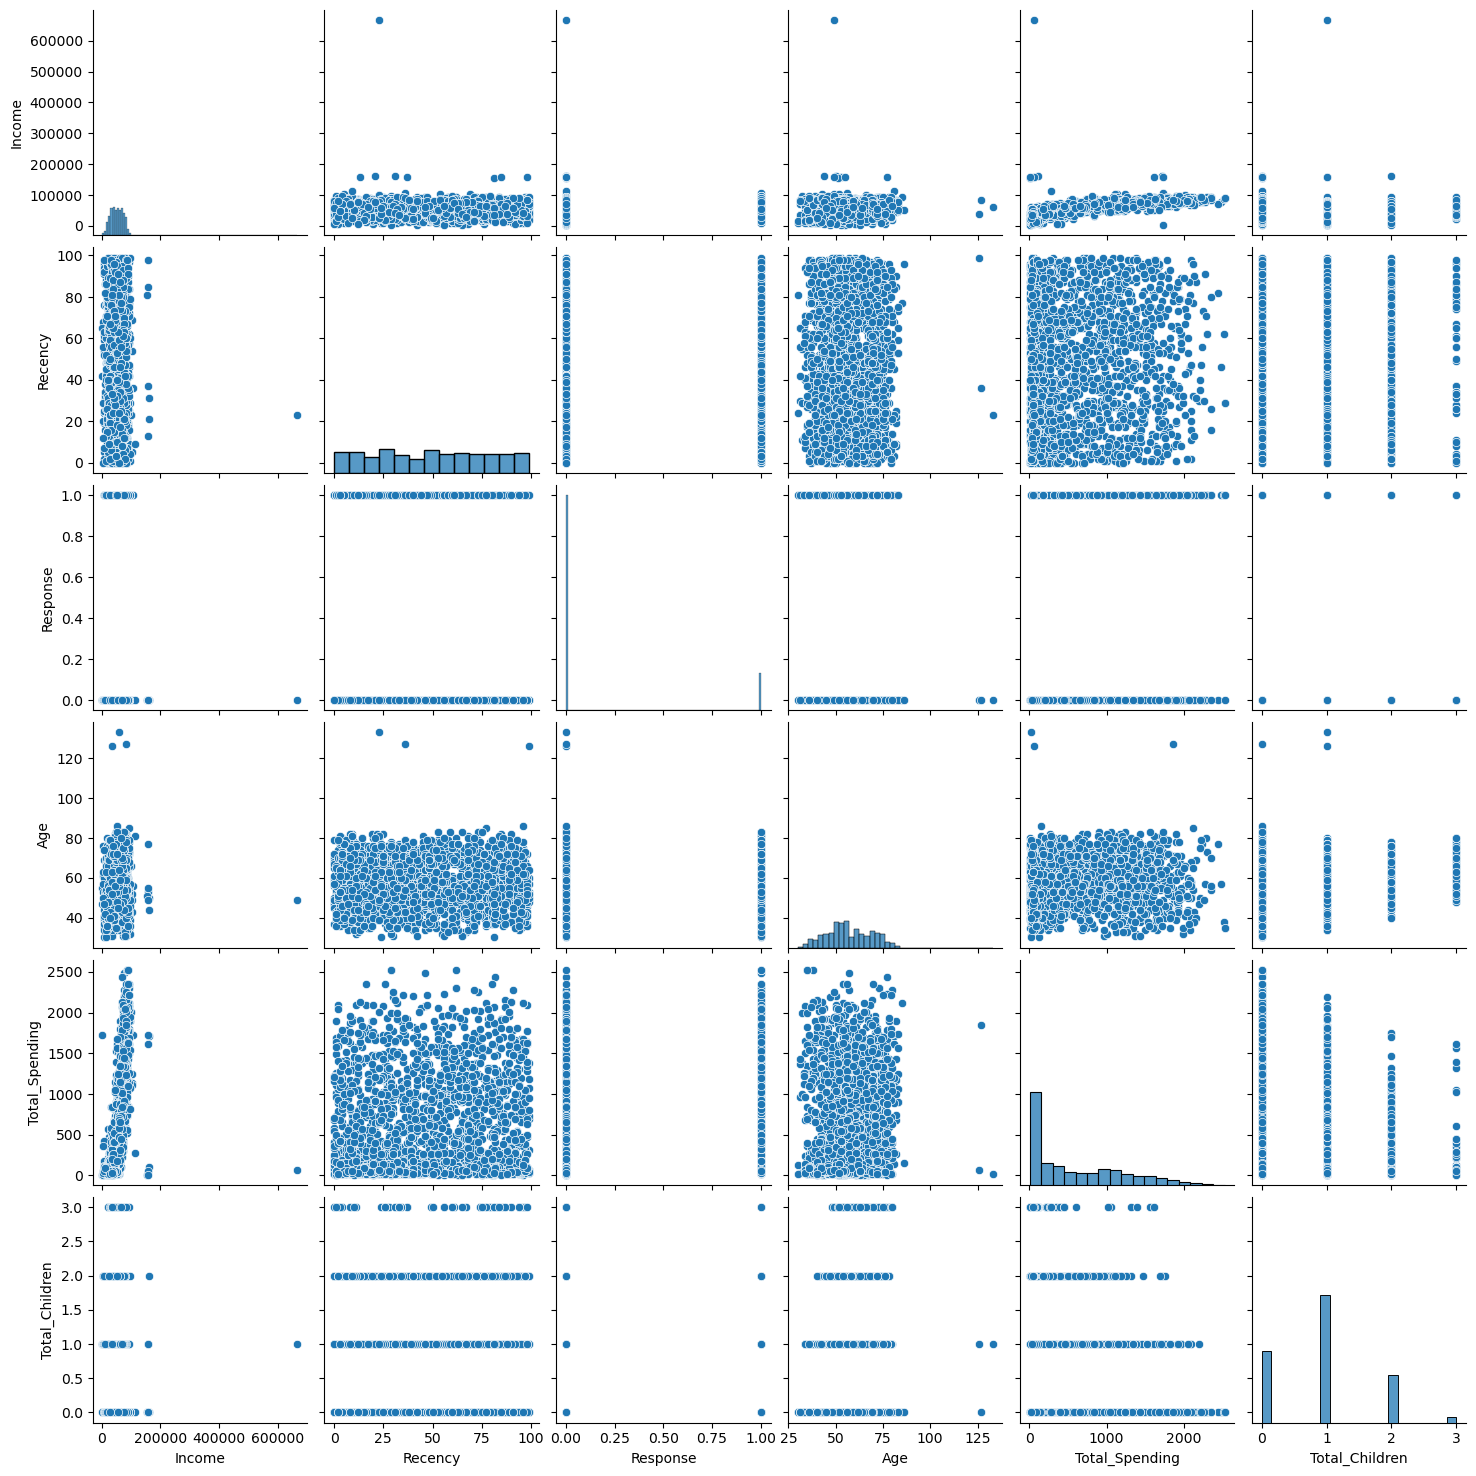

In [20]:
cols =["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# relative plots of some features - pair plotes for outliers
sns.pairplot(data_cleand[cols])

In [22]:
#remove outlier
print("datasize of outlier",len(data_cleand))
data_cleand =data_cleand[(data_cleand["Age"]<90)]
data_cleand =data_cleand[(data_cleand["Income"])<600000]
print("datasize of outlier",len(data_cleand))

datasize of outlier 2236
datasize of outlier 2236


HeatMap

In [23]:
corr =data_cleand.corr(numeric_only=True)

<Axes: >

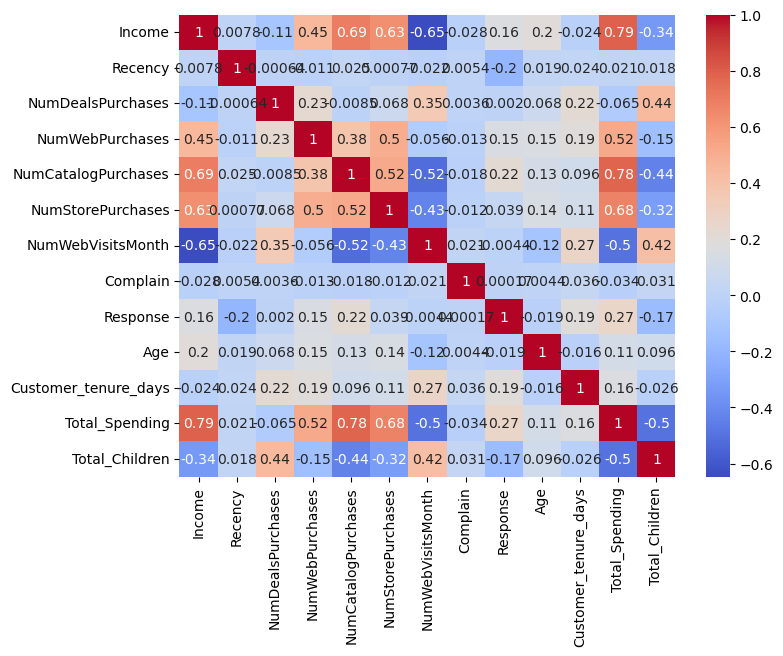

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
    
)

In [26]:
data_cleand.shape
data_cleand.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Living_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


Feature Incoding

In [27]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
# IN clustering problem we donot do DropFirst there is no problem multicolinearrity
ohe = OneHotEncoder()
cat_cols =["Education","Living_Status"]
enc_cols = ohe.fit_transform(data_cleand[cat_cols])

In [29]:
# enc_columns to convert it into array then change into dataframe,columns name,index 
enc_data =pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index = data_cleand.index)

In [30]:
data_encoded = pd.concat([data_cleand.drop(columns= cat_cols),enc_data],axis=1)

In [31]:
data_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


scaling are data

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
X=data_encoded

In [34]:
scaler =StandardScaler()
X_scaled=scaler.fit_transform(X)

Visualize the Data

In [35]:
# 3d visualization
from sklearn.decomposition import PCA

In [36]:
pca =PCA(n_components =3)
X_pca =pca.fit_transform(X_scaled)

In [37]:
pca.explained_variance_ratio_
# for 2d it campture only 0.34% variance

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

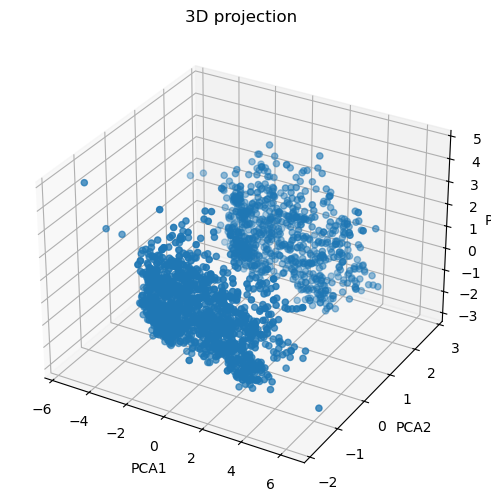

In [38]:
#plot 
fig =plt.figure(figsize = (8,6))
ax =fig.add_subplot(111,projection="3d") # 111 subgride
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

Analyze K value

1.Elbow Method

In [39]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss =[]
for k in range(1,11):
    kmeans =KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [40]:
knee =KneeLocator(range(1,11),wcss,curve ="convex",direction="decreasing")
optimal_k= knee.elbow

In [41]:
print("optimal k is = ",optimal_k)

optimal k is =  4


Text(0, 0.5, 'WCSS')

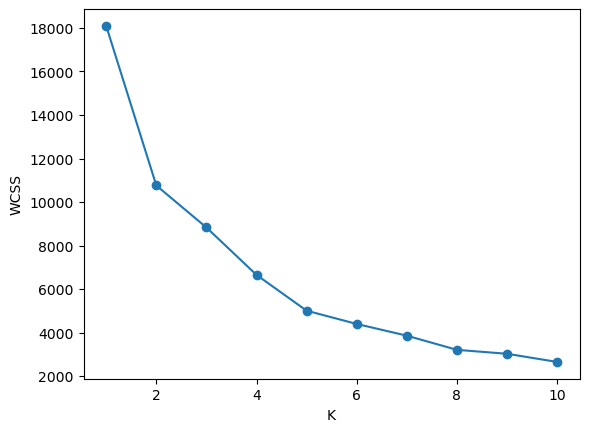

In [42]:
#plote
plt.plot(range(1,11),wcss,marker ="o")
plt.xlabel("K")
plt.ylabel("WCSS")

2.Silhoutte Score

In [43]:
from sklearn.metrics import silhouette_score 
scores=[]
for k in range(2,11):
    kmeans =KMeans(n_clusters=k,random_state=42)
    labels =kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels) 
    scores.append(score)

Text(0, 0.5, 'Silhouette Score')

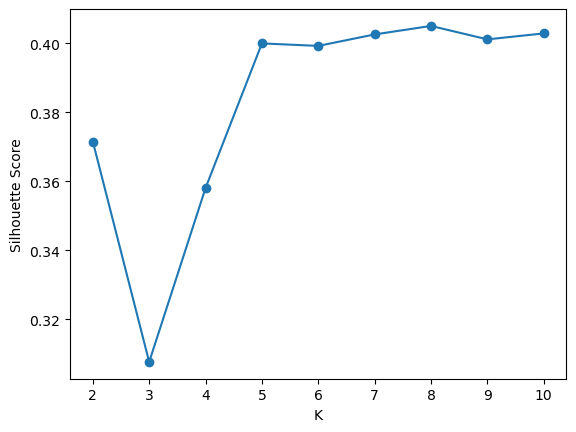

In [44]:
#plote
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'SS')

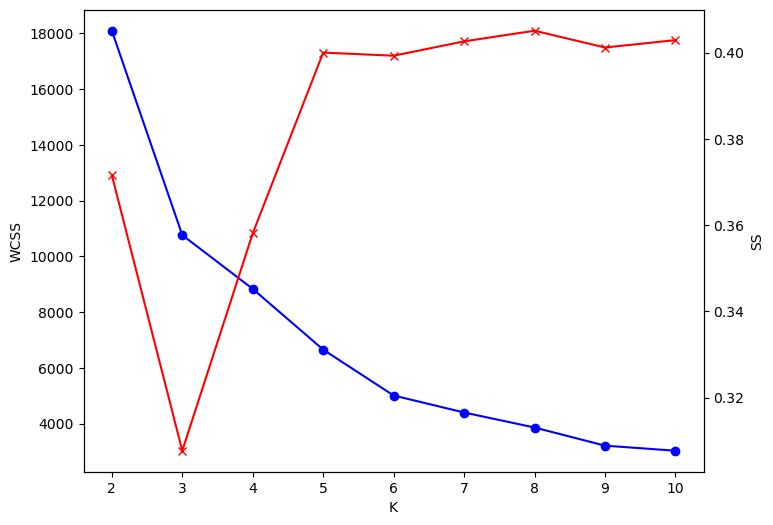

In [45]:
# combine plot
k_range =range(2,11)
fig, ax1 =plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker ="o",color ="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2 =ax1.twinx()   #use first x axis
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red")
ax2.set_ylabel("SS")


Clustering

In [46]:
from sklearn.cluster import KMeans
kmeans =KMeans(n_clusters=4,random_state=42)
labels_kmean =kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D projection')

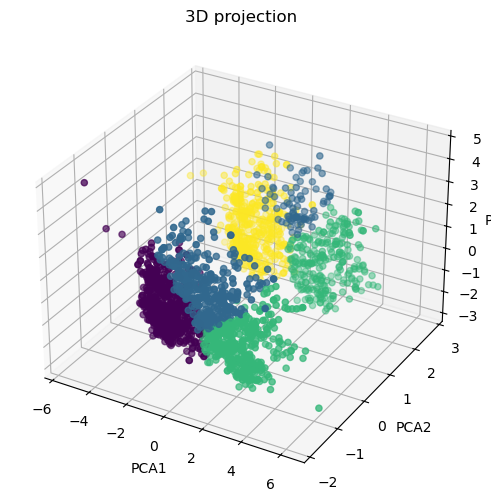

In [47]:
fig =plt.figure(figsize = (8,6))
ax =fig.add_subplot(111,projection="3d") # 111 subgride
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmean)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

Agglomerative Clustering

In [50]:
from sklearn.cluster import AgglomerativeClustering

In [51]:
agg_clus =AgglomerativeClustering(n_clusters =4,linkage="ward")
labels_agg =agg_clus.fit_predict(X_pca)

Text(0.5, 0.92, '3D projection')

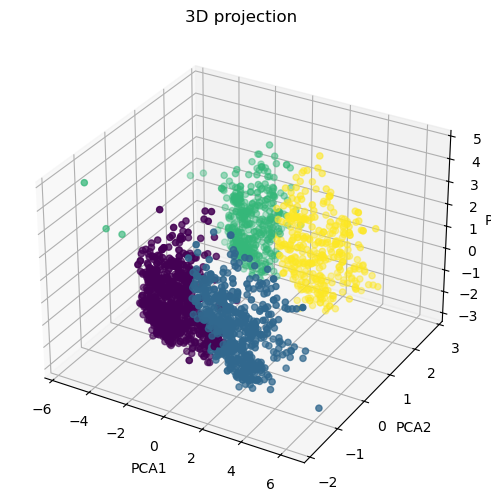

In [52]:
fig =plt.figure(figsize = (8,6))
ax =fig.add_subplot(111,projection="3d") # 111 subgride
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

Characterizaton Of Clusters

In [62]:
# from the cluster we identify the charecter of user or we identify the profile of customer
X["cluster"] =labels_agg

In [63]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


In [ ]:
# create plot to indentify information of each clusters
# no.of user in each clusters

<Axes: xlabel='cluster', ylabel='count'>

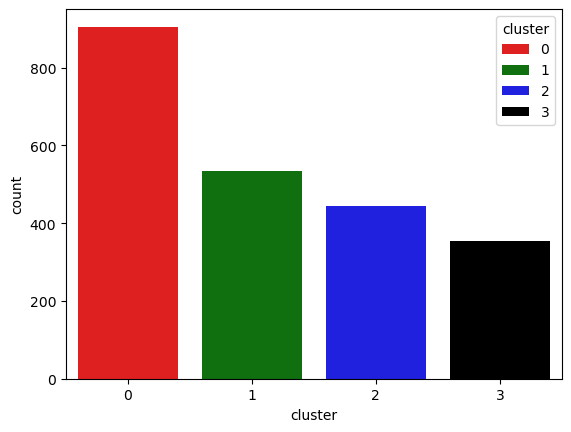

In [64]:
pal =["red","green","blue","black"]
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

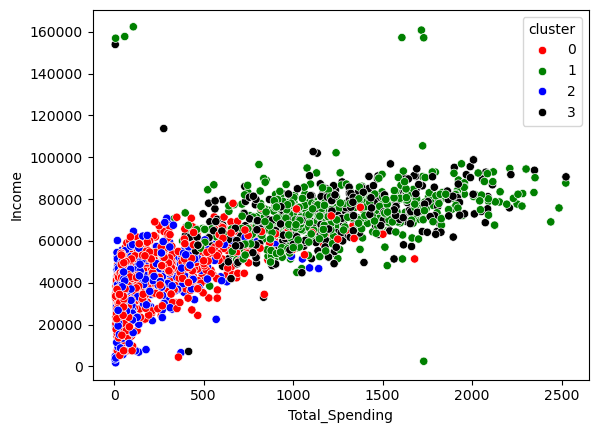

In [66]:
#plot of Income and Total Spending patterns becouse it has strong relation
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue =X["cluster"],palette=pal)

In [ ]:
# from this cluster we can identify the profile which have the no. of kids ,age
# cluster summary

In [67]:
cluster_summury =X.groupby("cluster").mean()
# accor to each cluster we calculate the mean value of all feature 
print(cluster_summury )

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_days  Total_Spending  \
cluster         